Aby powstrzymać atak z poprzedniego kroku, należy zmniejszyć dystans między rozkładem atrybutu wrażliwego w tej klasie $(P_{i})$, a rozkładem w całym zbiorze $(P_{G})$ tak, aby nie przekraczała progu $t$.

**Definicja:** Model $t$-bliskości wymaga, aby rozkład cechy wrażliwej w każdej grupie był bliski rozkładowi globalnemu:
$$d(P(S | EC_{i}), P(S))<t$$

- Oblicz dystans $d$ mi,ędzy histogramami, możesz użyć prostej różnicy wartości lub metryki EMD (Earth Mover's Distance).
- Skoryguj grupy tak, aby różnica była mniejsza niż zadany parametr $t$.
- Sprawdź ponownie atak z kroku 3 - czy teraz trudniej jest "wyłowić" informacje o ofierze?

<a href="https://medium.com/@TechSnazAI/earth-movers-distance-emd-or-wasserstein-distance-with-applications-e7c29a3b700a"> EMD </a> = Wasserstein Distance

In [2]:
import pandas as pd
import numpy as np
import kagglehub
import random
import scipy.stats as stats

path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(path + '/insurance.csv')

quasi_ids = ['age', 'sex', 'region', 'children']
sensitive_column = 'charges'

l_param = 7
t_param = 0.2

df['charges'] = (df['charges'] // 200) * 200

for col in ['sex', 'region', 'smoker']:
    df[col] = df[col].astype('category')

def get_spans(df, partition):
    spans = {}
    for col in quasi_ids:
        if df[col].dtype.name == 'category':
            spans[col] = len(df[col][partition].unique())
        else:
            spans[col] = df[col][partition].max() - df[col][partition].min()
    return spans

def split(df, partition, column):
    dfp = df[column][partition]
    if df[column].dtype.name == 'category':
        values = dfp.unique()
        lv = set(values[:len(values)//2])
        rv = set(values[len(values)//2:])
        return dfp.index[dfp.isin(lv)], dfp.index[dfp.isin(rv)]
    else:
        median = dfp.median()
        return dfp.index[dfp < median], dfp.index[dfp >= median]
    
def is_k_anonymous(lp, rp, k):
    if len(lp) >= k and len(rp) < k:
        return False
    return True

def is_l_diverse_entropy(df, partition, l):
    if len(partition) == 0:
        return False
    
    sensitive_values = df.loc[partition, sensitive_column]
        
    counts = sensitive_values.value_counts()
    probs = counts / len(sensitive_values)
    
    entropy = -np.sum(probs * np.log(probs))
        
    return entropy >= np.log(l)

def is_l_diverse(df, lp, rp, l):
    return is_l_diverse_entropy(df, lp, l) and is_l_diverse_entropy(df, rp, l)

def earth_movers_distance(values, global_probs):
    if len(values) == 0:
        return np.inf

    local_probs = values.value_counts(normalize=True)
    support = global_probs.index
    gp = global_probs.reindex(support, fill_value=0.0)
    lp = local_probs.reindex(support, fill_value=0.0)

    emd = stats.wasserstein_distance(
        support, support, u_weights=lp.to_numpy(), v_weights=gp.to_numpy()
    )

    value_range = support[-1] - support[0]
    return emd / value_range if value_range > 0 else 0.0

def histogram_distance(df, partition, P_G, bins):
    local_sensitive = df.loc[partition, sensitive_column]
    local_hist, _ = np.histogram(local_sensitive, bins=bins)
    P_i = local_hist / local_hist.sum()
    return np.abs(P_i - P_G)

def is_t_close_EMD(df, partition, global_probs, t):
    values = df.loc[partition, sensitive_column]
    return earth_movers_distance(values, global_probs) <= t

def is_t_close_histogram(df, partition, P_G, bins, t):
    distance = histogram_distance(df, partition, P_G, bins)
    return np.all(distance <= t)

def is_t_close_pair_EMD(df, lp, rp, global_probs, t):
    return is_t_close_EMD(df, lp, global_probs, t) and is_t_close_EMD(df, rp, global_probs, t)

def is_t_close_pair_histogram(df, lp, rp, P_G, bins, t):
    return is_t_close_histogram(df, lp, P_G, bins, t) and is_t_close_histogram(df, rp, P_G, bins, t)

def mondrian(df, partition, k=10, l=2, t=0.2, global_probs=None, P_G=None, bins=None):
    if global_probs is None:
        global_probs = df[sensitive_column].value_counts(normalize=True)

    if len(partition) < 2 * k:
        return [partition]

    spans = get_spans(df, partition)
    columns = list(spans.keys())
    random.shuffle(columns)

    if P_G is not None and bins is not None:
        for column in columns:
            lp, rp = split(df, partition, column)
            if (
                is_k_anonymous(lp, rp, k)
                and is_l_diverse(df, lp, rp, l)
                and is_t_close_pair_histogram(df, lp, rp, P_G, bins, t)
            ):
                return (
                    mondrian(df, lp, k, l, t, P_G=P_G, bins=bins)
                    + mondrian(df, rp, k, l, t, P_G=P_G, bins=bins)
                )
        return [partition]
    else:    
        for column in columns:
            lp, rp = split(df, partition, column)
            if (
                is_k_anonymous(lp, rp, k)
                and is_l_diverse(df, lp, rp, l)
                and is_t_close_pair_EMD(df, lp, rp, global_probs, t)
            ):
                return (
                    mondrian(df, lp, k, l, t, global_probs=global_probs)
                    + mondrian(df, rp, k, l, t, global_probs=global_probs)
                )
        return [partition]

global_sensitive = df[sensitive_column]

bins = np.histogram_bin_edges(global_sensitive, bins=20)
global_hist, _ = np.histogram(global_sensitive, bins=bins)
P_G = global_hist / global_hist.sum()

global_sensitive_probs = df[sensitive_column].value_counts(normalize=True)

finished_partitions_histogram = mondrian(
    df, df.index, k=25, l=l_param, t=t_param, P_G=P_G, bins=bins)

finished_partitions_emd = mondrian(
    df, df.index, k=25, l=l_param, t=t_param, global_probs=global_sensitive_probs)

In [ ]:
rows = []
for part in finished_partitions_histogram:
    group = df.loc[part]
    agg_vals = {}
    for col in quasi_ids:
        if df[col].dtype.name == 'category':
            agg_vals[col] = ", ".join(group[col].unique())
        else:
            agg_vals[col] = f"{group[col].min()}-{group[col].max()}"
    agg_vals['charges_mean'] = group['charges'].mean()
    agg_vals['count'] = len(group)
    agg_vals['emd_distance'] = earth_movers_distance(
        group[sensitive_column], global_sensitive_probs
    )
    agg_vals['histogram_distance'] = np.max(histogram_distance(group, part, P_G, bins))
    rows.append(agg_vals)

df_summary = pd.DataFrame(rows)
df_summary

,age,sex,region,children,charges_mean,count,emd_distance,histogram_distance
0,19-64,female,southwest,0-0,10049.275362,69,0.119282,0.136316
1,18-64,female,southeast,0-0,14776.315789,76,0.104528,0.130596
2,19-64,female,northwest,0-0,12491.666667,72,0.048661,0.105755
3,18-64,female,northeast,0-0,9702.777778,72,0.134660,0.149601
4,19-64,male,northwest,0-0,9716.666667,60,0.131429,0.171824
5,18-64,male,northeast,0-0,13282.666667,75,0.057176,0.135755
6,19-64,male,southwest,0-0,13626.086957,69,0.061059,0.102132
7,18-64,male,southeast,0-0,13676.543210,81,0.092352,0.158861
8,18-64,male,southeast,1-1,17320.833333,48,0.163579,0.064088
9,18-64,male,southeast,2-5,17350.000000,60,0.161551,0.161510


In [7]:
rows = []
for part in finished_partitions_emd:
    group = df.loc[part]
    agg_vals = {}
    for col in quasi_ids:
        if df[col].dtype.name == 'category':
            agg_vals[col] = ", ".join(group[col].unique())
        else:
            agg_vals[col] = f"{group[col].min()}-{group[col].max()}"
    agg_vals['charges_mean'] = group['charges'].mean()
    agg_vals['count'] = len(group)
    agg_vals['emd_distance'] = earth_movers_distance(
        group[sensitive_column], global_sensitive_probs
    )
    agg_vals['histogram_distance'] = np.max(histogram_distance(group, part, P_G, bins))
    rows.append(agg_vals)

df_summary = pd.DataFrame(rows)
df_summary

,age,sex,region,children,charges_mean,count,emd_distance,histogram_distance
0,19-31,female,southwest,0-0,7969.696970,33,0.197602,0.485460
1,32-64,female,southwest,0-0,11955.555556,36,0.165334,0.297210
2,18-64,female,southeast,0-0,14776.315789,76,0.104528,0.130596
3,19-36,female,northwest,0-0,9150.000000,36,0.168321,0.399601
4,41-64,female,northwest,0-0,15833.333333,36,0.151221,0.213876
5,18-64,female,northeast,0-0,9702.777778,72,0.134660,0.149601
6,19-64,male,northwest,0-0,9716.666667,60,0.131429,0.171824
7,18-34,male,northeast,0-0,9108.108108,37,0.161401,0.410112
8,39-64,male,northeast,0-0,17347.368421,38,0.166768,0.273818
9,19-38,male,southwest,0-0,11503.030303,33,0.184187,0.364248


In [11]:
import matplotlib.pyplot as plt

def attack(df, tau=0.10, finished_partitions=finished_partitions_histogram):
    # 1) Wybierz losową ofiarę i znajdź jej klasę równoważności EC_i
    victim_idx = np.random.choice(df.index)
    victim_record = df.loc[victim_idx]

    victim_partition = None
    for part in finished_partitions:
        if victim_idx in part:
            victim_partition = part
            break

    if victim_partition is None:
        raise RuntimeError("Nie znaleziono grupy EC_i dla wybranej ofiary.")

    local_sensitive = df.loc[victim_partition, sensitive_column]
    global_sensitive = df[sensitive_column]

    # 2) Histogram globalny i lokalny (te same koszyki dla porównywalności)
    bins = np.histogram_bin_edges(global_sensitive, bins=20)
    global_hist, _ = np.histogram(global_sensitive, bins=bins)
    local_hist, _ = np.histogram(local_sensitive, bins=bins)

    # Znormalizowane rozkłady: P_G(s) i P_i(s)
    P_G = global_hist / global_hist.sum()
    P_i = local_hist / local_hist.sum()

    # 3) Test ataku skośności: max_s |P_i(s)-P_G(s)| > tau
    diff = np.abs(P_i - P_G)
    max_diff = diff.max()
    attack_success = max_diff > tau


    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    axes[0].hist(global_sensitive, bins=bins, density=True, alpha=0.75, color="#1f77b4", edgecolor="black")
    axes[0].set_title("Histogram Globalny P_G(s)")
    axes[0].set_xlabel(sensitive_column)
    axes[0].set_ylabel("Gęstość")

    axes[1].hist(local_sensitive, bins=bins, density=True, alpha=0.75, color="#ff7f0e", edgecolor="black")
    axes[1].set_title("Histogram Lokalny P_i(s) (EC_i ofiary)")
    axes[1].set_xlabel(sensitive_column)

    plt.tight_layout()
    plt.show()


    print(f"Ofiara (index): {victim_idx}")
    print("Ofiara (QI):", victim_record[quasi_ids].to_dict())
    print(f"Rozmiar EC_i: {len(victim_partition)}")
    print(f"tau = {tau:.2f}")
    print(f"max_s |P_i(s)-P_G(s)| = {max_diff:.4f}")
    print("Wynik ataku:", "UDANY" if attack_success else "NIEUDANY")

    # Podgląd największych odchyleń między P_i i P_G
    bin_labels = [f"[{int(bins[i])}, {int(bins[i+1])})" for i in range(len(bins) - 1)]
    diff_df = pd.DataFrame({
        "bin": bin_labels,
        "P_G": P_G,
        "P_i": P_i,
        "abs_diff": diff
    }).sort_values("abs_diff", ascending=False)

    print(diff_df.head(10))

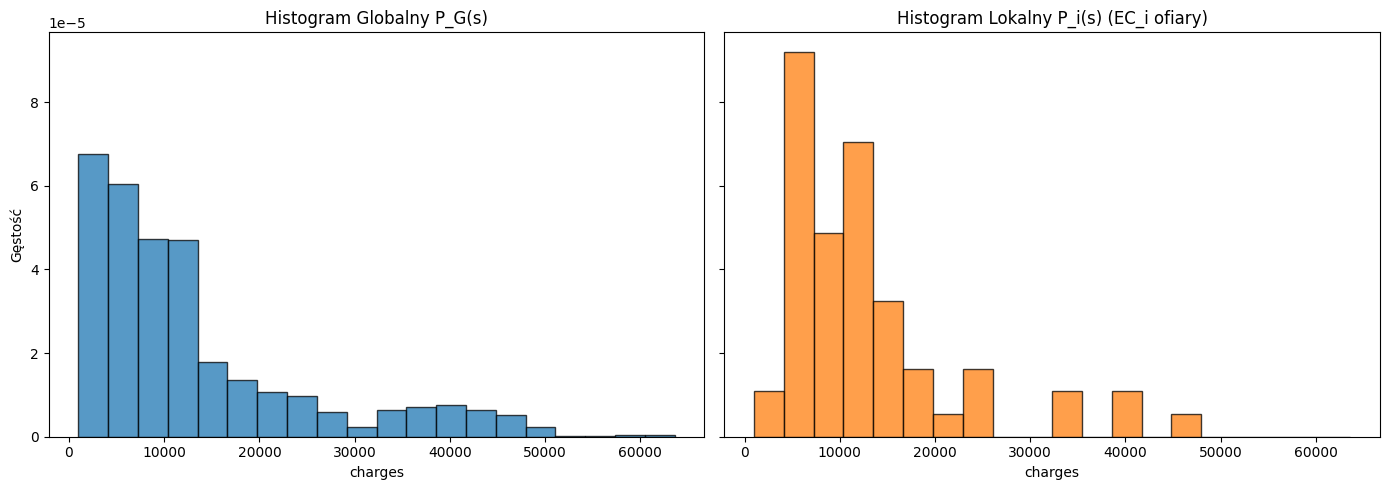

Ofiara (index): 994
Ofiara (QI): {'age': 27, 'sex': 'female', 'region': 'northwest', 'children': 3}
Rozmiar EC_i: 59
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.1776
Wynik ataku: NIEUDANY
               bin       P_G       P_i  abs_diff
0     [1000, 4130)  0.211510  0.033898  0.177611
1     [4130, 7260)  0.189088  0.288136  0.099047
3   [10390, 13520)  0.147235  0.220339  0.073104
4   [13520, 16650)  0.056054  0.101695  0.045641
11  [35430, 38560)  0.022422  0.000000  0.022422
7   [22910, 26040)  0.030643  0.050847  0.020205
13  [41690, 44820)  0.020179  0.000000  0.020179
8   [26040, 29170)  0.018685  0.000000  0.018685
6   [19780, 22910)  0.033632  0.016949  0.016683
10  [32300, 35430)  0.020179  0.033898  0.013719


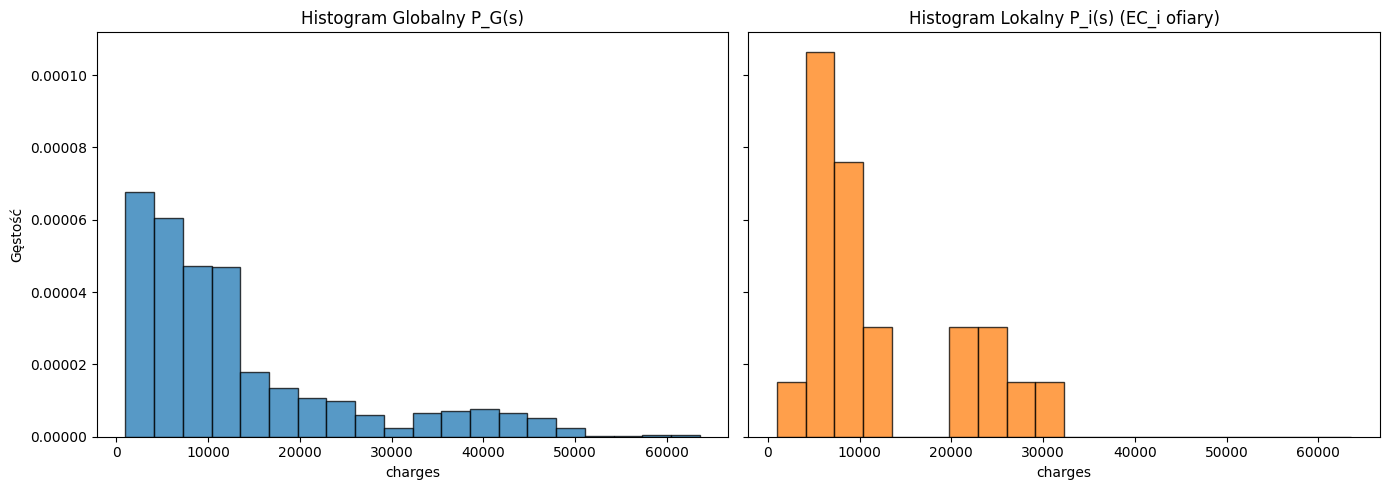

Ofiara (index): 925
Ofiara (QI): {'age': 50, 'sex': 'male', 'region': 'northeast', 'children': 2}
Rozmiar EC_i: 21
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.1639
Wynik ataku: NIEUDANY
              bin       P_G       P_i  abs_diff
0    [1000, 4130)  0.211510  0.047619  0.163891
1    [4130, 7260)  0.189088  0.333333  0.144245
2   [7260, 10390)  0.147982  0.238095  0.090113
7  [22910, 26040)  0.030643  0.095238  0.064595
6  [19780, 22910)  0.033632  0.095238  0.061606
4  [13520, 16650)  0.056054  0.000000  0.056054
3  [10390, 13520)  0.147235  0.095238  0.051997
5  [16650, 19780)  0.042601  0.000000  0.042601
9  [29170, 32300)  0.007474  0.047619  0.040145
8  [26040, 29170)  0.018685  0.047619  0.028934


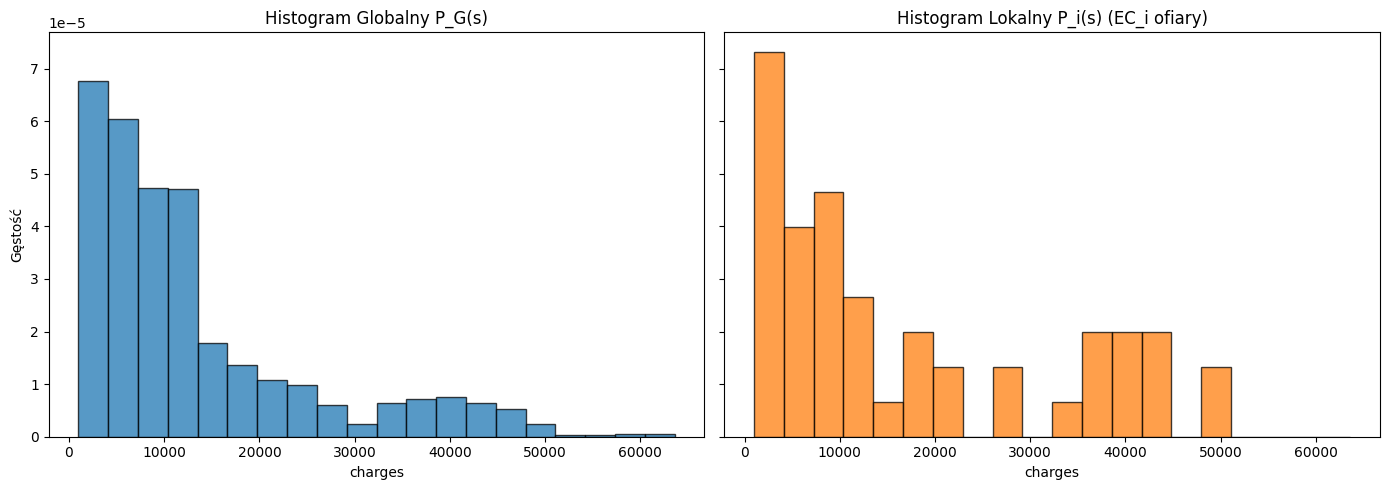

Ofiara (index): 418
Ofiara (QI): {'age': 64, 'sex': 'male', 'region': 'southeast', 'children': 1}
Rozmiar EC_i: 48
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.0641
Wynik ataku: NIEUDANY
               bin       P_G       P_i  abs_diff
1     [4130, 7260)  0.189088  0.125000  0.064088
3   [10390, 13520)  0.147235  0.083333  0.063901
13  [41690, 44820)  0.020179  0.062500  0.042321
11  [35430, 38560)  0.022422  0.062500  0.040078
12  [38560, 41690)  0.023916  0.062500  0.038584
4   [13520, 16650)  0.056054  0.020833  0.035220
15  [47950, 51080)  0.007474  0.041667  0.034193
7   [22910, 26040)  0.030643  0.000000  0.030643
8   [26040, 29170)  0.018685  0.041667  0.022982
5   [16650, 19780)  0.042601  0.062500  0.019899


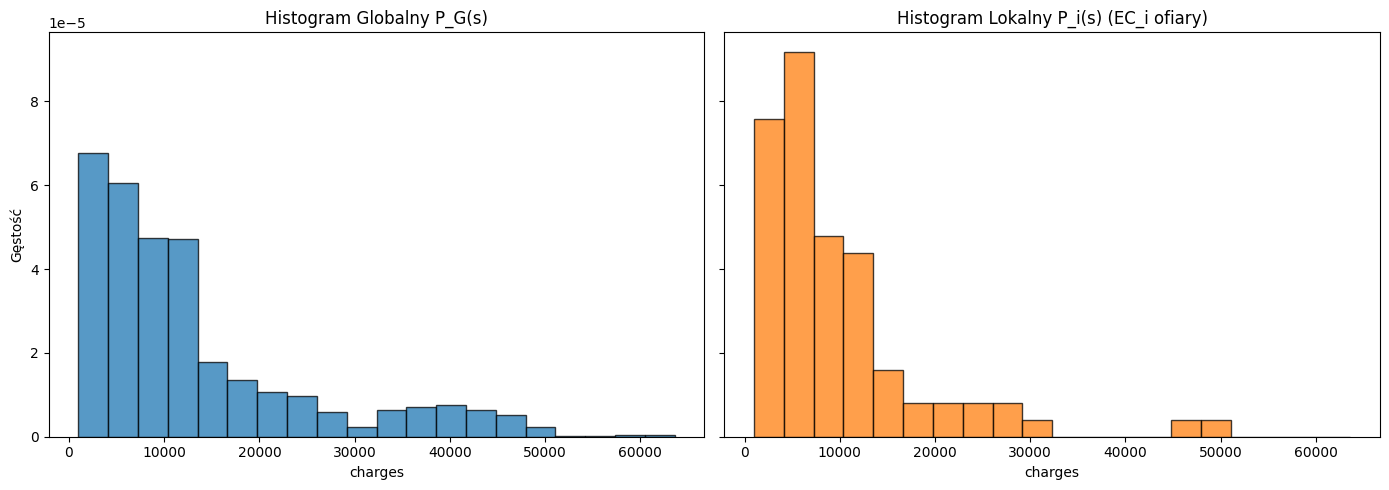

Ofiara (index): 434
Ofiara (QI): {'age': 31, 'sex': 'male', 'region': 'northwest', 'children': 1}
Rozmiar EC_i: 80
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.0984
Wynik ataku: NIEUDANY
               bin       P_G     P_i  abs_diff
1     [4130, 7260)  0.189088  0.2875  0.098412
0     [1000, 4130)  0.211510  0.2375  0.025990
12  [38560, 41690)  0.023916  0.0000  0.023916
11  [35430, 38560)  0.022422  0.0000  0.022422
13  [41690, 44820)  0.020179  0.0000  0.020179
10  [32300, 35430)  0.020179  0.0000  0.020179
5   [16650, 19780)  0.042601  0.0250  0.017601
3   [10390, 13520)  0.147235  0.1375  0.009735
6   [19780, 22910)  0.033632  0.0250  0.008632
8   [26040, 29170)  0.018685  0.0250  0.006315


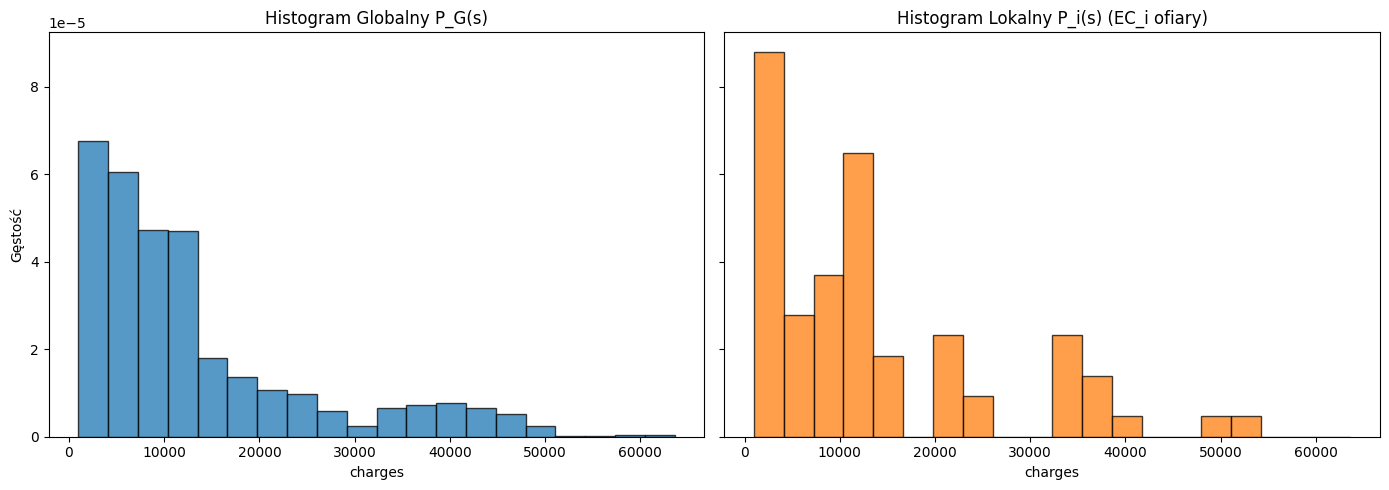

Ofiara (index): 99
Ofiara (QI): {'age': 38, 'sex': 'male', 'region': 'southwest', 'children': 0}
Rozmiar EC_i: 69
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.1021
Wynik ataku: NIEUDANY
               bin       P_G       P_i  abs_diff
1     [4130, 7260)  0.189088  0.086957  0.102132
0     [1000, 4130)  0.211510  0.275362  0.063853
3   [10390, 13520)  0.147235  0.202899  0.055664
10  [32300, 35430)  0.020179  0.072464  0.052284
5   [16650, 19780)  0.042601  0.000000  0.042601
6   [19780, 22910)  0.033632  0.072464  0.038831
2    [7260, 10390)  0.147982  0.115942  0.032040
11  [35430, 38560)  0.022422  0.043478  0.021057
13  [41690, 44820)  0.020179  0.000000  0.020179
8   [26040, 29170)  0.018685  0.000000  0.018685


In [12]:
for _ in range(5):
    attack(df, tau=0.20, finished_partitions=finished_partitions_histogram)

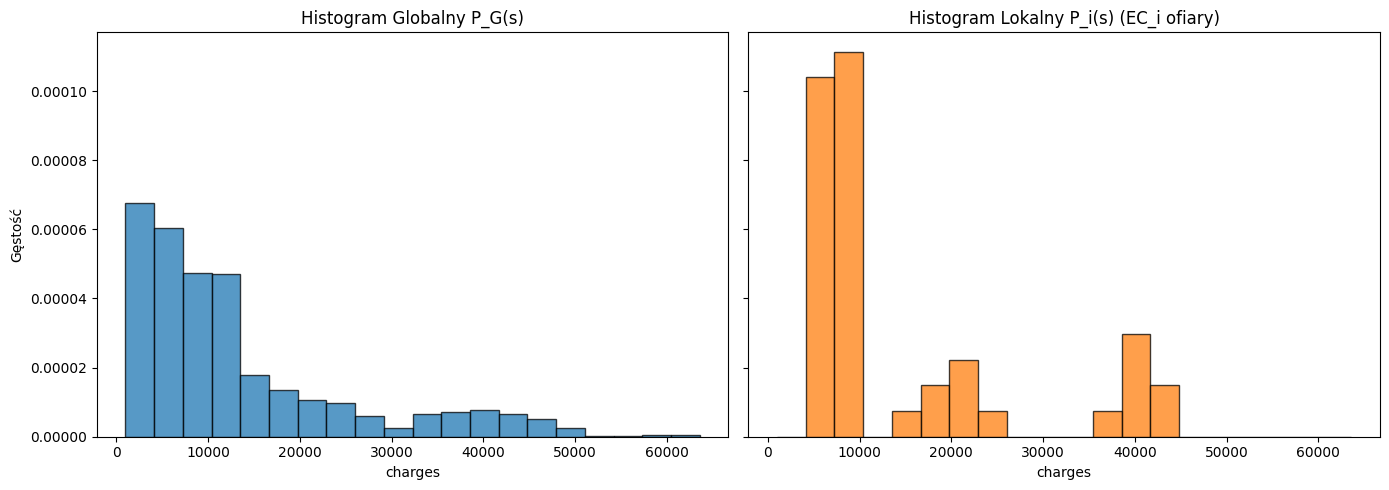

Ofiara (index): 907
Ofiara (QI): {'age': 44, 'sex': 'female', 'region': 'southeast', 'children': 1}
Rozmiar EC_i: 43
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.2115
Wynik ataku: UDANY
               bin       P_G       P_i  abs_diff
0     [1000, 4130)  0.211510  0.000000  0.211510
2    [7260, 10390)  0.147982  0.348837  0.200855
3   [10390, 13520)  0.147235  0.000000  0.147235
1     [4130, 7260)  0.189088  0.325581  0.136493
12  [38560, 41690)  0.023916  0.093023  0.069107
6   [19780, 22910)  0.033632  0.069767  0.036135
4   [13520, 16650)  0.056054  0.023256  0.032798
13  [41690, 44820)  0.020179  0.046512  0.026332
10  [32300, 35430)  0.020179  0.000000  0.020179
8   [26040, 29170)  0.018685  0.000000  0.018685


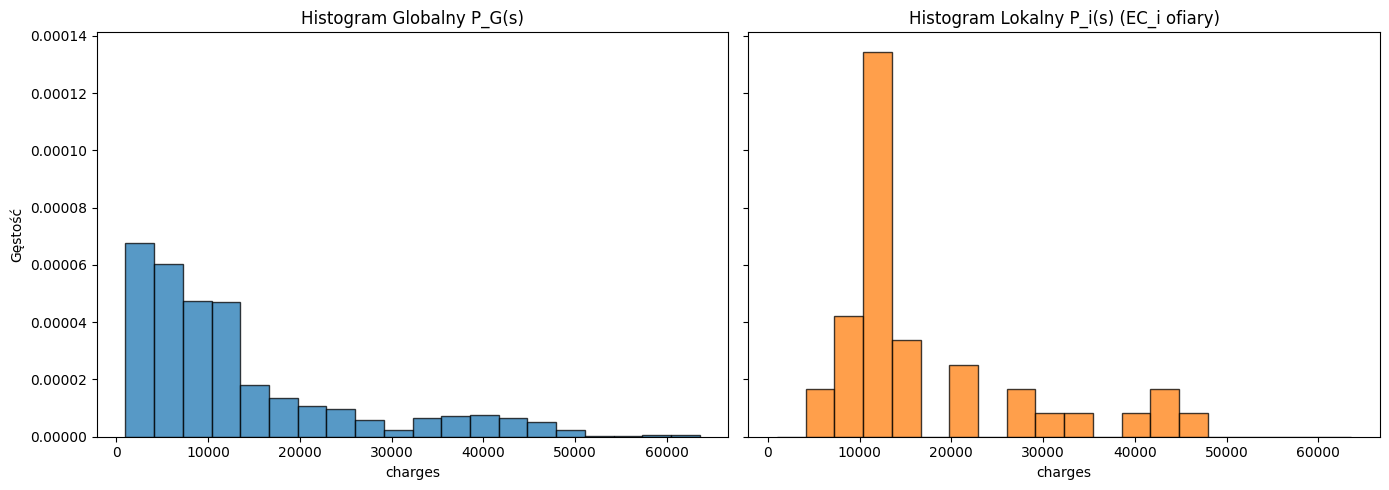

Ofiara (index): 917
Ofiara (QI): {'age': 45, 'sex': 'male', 'region': 'northeast', 'children': 0}
Rozmiar EC_i: 38
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.2738
Wynik ataku: UDANY
               bin       P_G       P_i  abs_diff
3   [10390, 13520)  0.147235  0.421053  0.273818
0     [1000, 4130)  0.211510  0.000000  0.211510
1     [4130, 7260)  0.189088  0.052632  0.136457
4   [13520, 16650)  0.056054  0.105263  0.049209
6   [19780, 22910)  0.033632  0.078947  0.045315
5   [16650, 19780)  0.042601  0.000000  0.042601
8   [26040, 29170)  0.018685  0.052632  0.033947
13  [41690, 44820)  0.020179  0.052632  0.032452
7   [22910, 26040)  0.030643  0.000000  0.030643
11  [35430, 38560)  0.022422  0.000000  0.022422


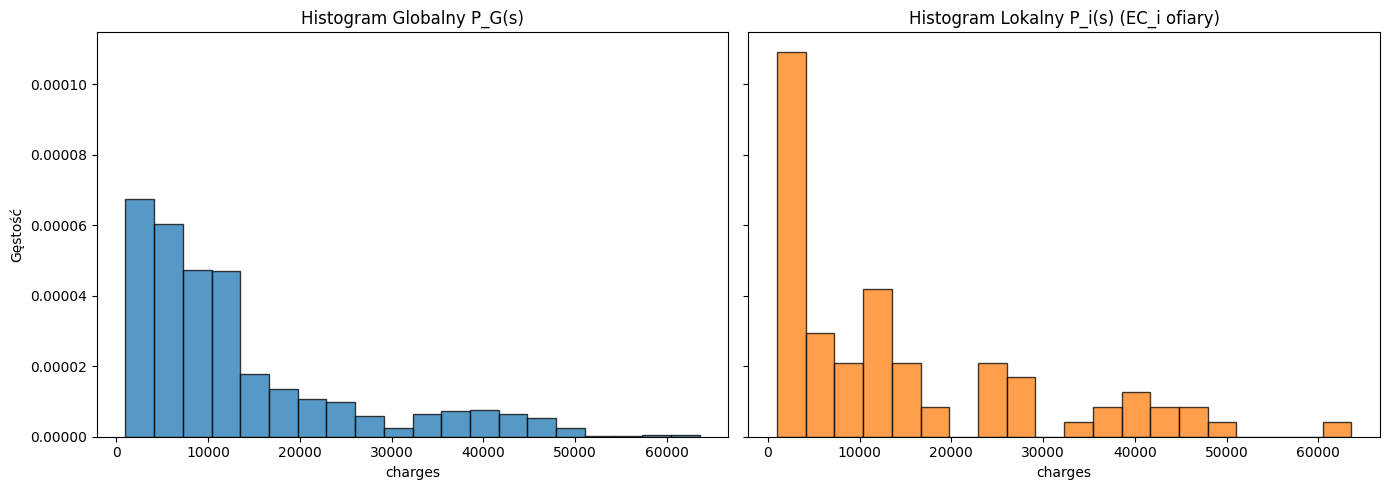

Ofiara (index): 743
Ofiara (QI): {'age': 31, 'sex': 'female', 'region': 'southeast', 'children': 0}
Rozmiar EC_i: 76
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.1306
Wynik ataku: NIEUDANY
               bin       P_G       P_i  abs_diff
0     [1000, 4130)  0.211510  0.342105  0.130596
1     [4130, 7260)  0.189088  0.092105  0.096983
2    [7260, 10390)  0.147982  0.065789  0.082193
7   [22910, 26040)  0.030643  0.065789  0.035147
8   [26040, 29170)  0.018685  0.052632  0.033947
6   [19780, 22910)  0.033632  0.000000  0.033632
5   [16650, 19780)  0.042601  0.026316  0.016285
3   [10390, 13520)  0.147235  0.131579  0.015656
12  [38560, 41690)  0.023916  0.039474  0.015557
19  [60470, 63600)  0.001495  0.013158  0.011663


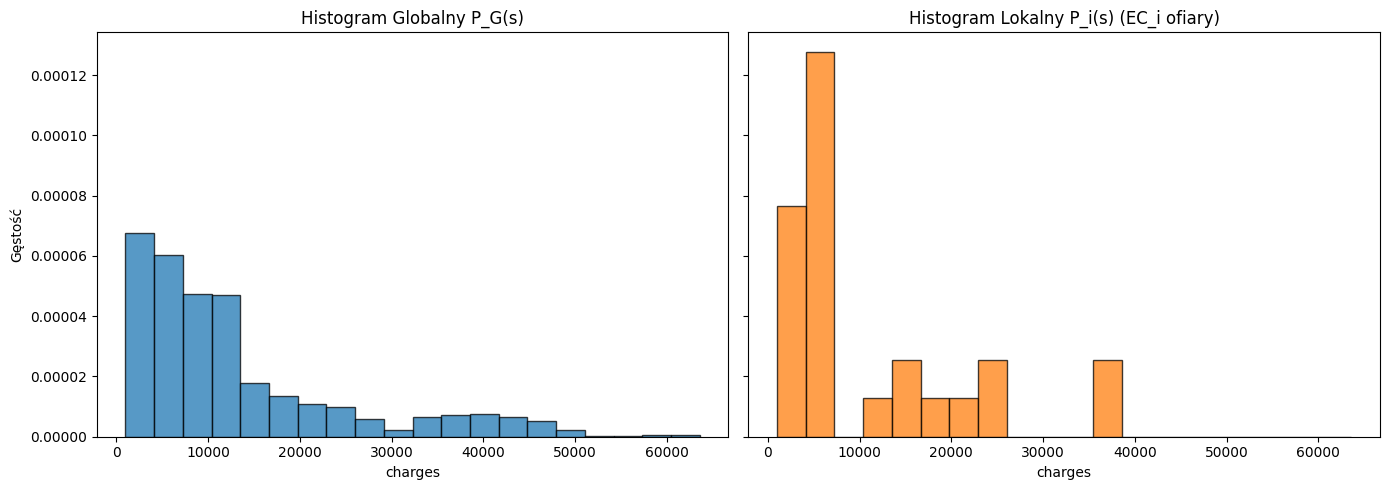

Ofiara (index): 240
Ofiara (QI): {'age': 23, 'sex': 'female', 'region': 'northeast', 'children': 2}
Rozmiar EC_i: 25
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.2109
Wynik ataku: UDANY
               bin       P_G   P_i  abs_diff
1     [4130, 7260)  0.189088  0.40  0.210912
2    [7260, 10390)  0.147982  0.00  0.147982
3   [10390, 13520)  0.147235  0.04  0.107235
11  [35430, 38560)  0.022422  0.08  0.057578
7   [22910, 26040)  0.030643  0.08  0.049357
0     [1000, 4130)  0.211510  0.24  0.028490
4   [13520, 16650)  0.056054  0.08  0.023946
12  [38560, 41690)  0.023916  0.00  0.023916
13  [41690, 44820)  0.020179  0.00  0.020179
10  [32300, 35430)  0.020179  0.00  0.020179


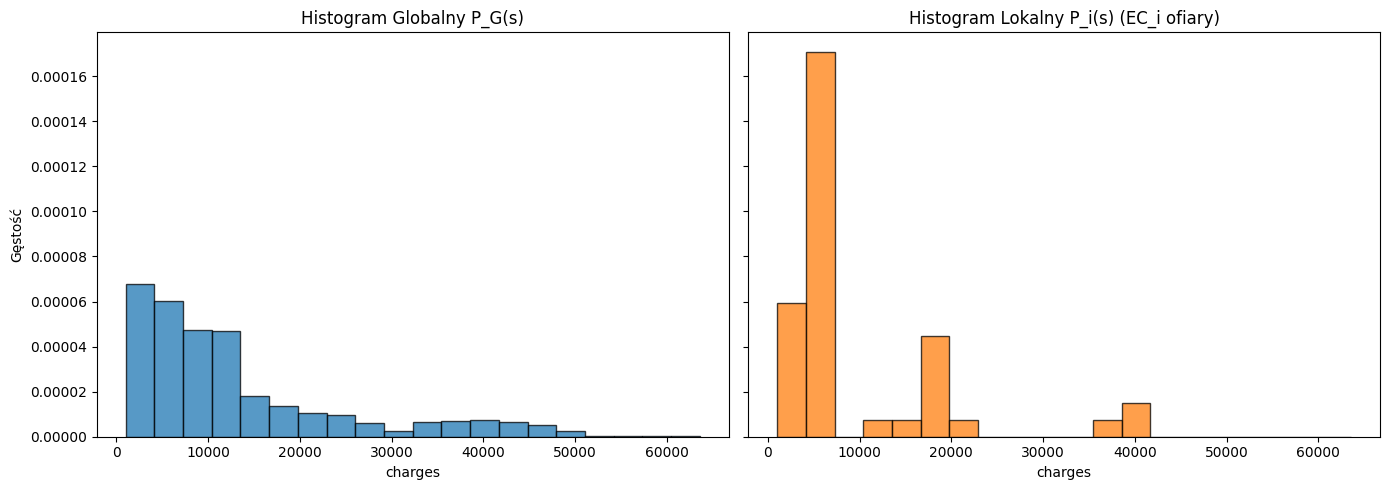

Ofiara (index): 49
Ofiara (QI): {'age': 36, 'sex': 'male', 'region': 'southeast', 'children': 1}
Rozmiar EC_i: 43
tau = 0.20
max_s |P_i(s)-P_G(s)| = 0.3458
Wynik ataku: UDANY
               bin       P_G       P_i  abs_diff
1     [4130, 7260)  0.189088  0.534884  0.345796
2    [7260, 10390)  0.147982  0.000000  0.147982
3   [10390, 13520)  0.147235  0.023256  0.123979
5   [16650, 19780)  0.042601  0.139535  0.096934
4   [13520, 16650)  0.056054  0.023256  0.032798
7   [22910, 26040)  0.030643  0.000000  0.030643
0     [1000, 4130)  0.211510  0.186047  0.025463
12  [38560, 41690)  0.023916  0.046512  0.022595
13  [41690, 44820)  0.020179  0.000000  0.020179
10  [32300, 35430)  0.020179  0.000000  0.020179


In [13]:
for _ in range(5):
    attack(df, tau=0.20, finished_partitions=finished_partitions_emd)